In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, LassoCV
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("GDSC_DATASET.csv")
df = df.drop(columns=["AUC", "Z_SCORE"], errors="ignore")

print("Shape:", df.shape)
df.head()

Shape: (242035, 17)


,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication


In [4]:
target_col = "LN_IC50"

feature_cols = [
    "TCGA_DESC",
    "GDSC Tissue descriptor 1",
    "GDSC Tissue descriptor 2",
    "Cancer Type (matching TCGA label)",
    "Microsatellite instability Status (MSI)",
    "Screen Medium",
    "Growth Properties",
    "CNA",
    "Gene Expression",
    "Methylation",
    "TARGET",
    "TARGET_PATHWAY"
]

model_df = df[feature_cols + [target_col]].copy()

# Drop missing target
model_df = model_df.dropna(subset=[target_col])

In [6]:
# Separate X and y
X = model_df[feature_cols].copy()   # IMPORTANT FIX
y = model_df[target_col]

# Binary mapping
binary_cols = ["CNA", "Gene Expression", "Methylation"]

for col in binary_cols:
    X[col] = X[col].map({"Y": 1, "N": 0})

# Fill missing
X = X.fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Convert bool → int
X = X.astype(int)

print("Final shape:", X.shape)

Final shape: (242035, 357)


In [7]:
# Test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train + Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (145221, 357)
Val: (48407, 357)
Test: (48407, 357)


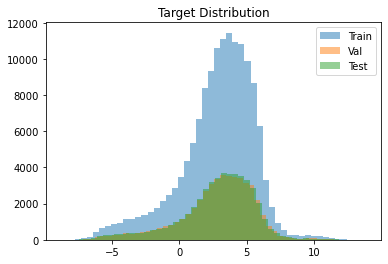

In [8]:
plt.hist(y_train, bins=50, alpha=0.5, label="Train")
plt.hist(y_val, bins=50, alpha=0.5, label="Val")
plt.hist(y_test, bins=50, alpha=0.5, label="Test")

plt.legend()
plt.title("Target Distribution")
plt.show()

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)

print("\nLinear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_lr)))
print("MAE :", mean_absolute_error(y_val, y_pred_lr))
print("R2  :", r2_score(y_val, y_pred_lr))


Linear Regression
RMSE: 1.5739602463435116
MAE : 1.1845411081900603
R2  : 0.6712299878301434


In [10]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_val)

print("\nRidge Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_ridge)))
print("MAE :", mean_absolute_error(y_val, y_pred_ridge))
print("R2  :", r2_score(y_val, y_pred_ridge))


Ridge Regression
RMSE: 1.573383285245617
MAE : 1.1840760649935245
R2  : 0.6714709757980089


In [11]:
lasso = LassoCV(cv=5, max_iter=10000, n_jobs=-1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_val)

print("\nLasso Regression")
print("Best alpha:", lasso.alpha_)
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_lasso)))
print("MAE :", mean_absolute_error(y_val, y_pred_lasso))
print("R2  :", r2_score(y_val, y_pred_lasso))


Lasso Regression
Best alpha: 0.0001983703981421993
RMSE: 1.5744989607703483
MAE : 1.1859758505796054
R2  : 0.6710048951582552


In [12]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

print("\nRandom Forest")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_rf)))
print("MAE :", mean_absolute_error(y_val, y_pred_rf))
print("R2  :", r2_score(y_val, y_pred_rf))


Random Forest
RMSE: 2.2036210492688033
MAE : 1.7212400203285123
R2  : 0.3555659135679681


In [13]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "Random Forest"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, y_pred_lr)),
        np.sqrt(mean_squared_error(y_val, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_val, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_val, y_pred_rf))
    ],
    "R2": [
        r2_score(y_val, y_pred_lr),
        r2_score(y_val, y_pred_ridge),
        r2_score(y_val, y_pred_lasso),
        r2_score(y_val, y_pred_rf)
    ]
})

results

,Model,RMSE,R2
0,Linear,1.573960,0.671230
1,Ridge,1.573383,0.671471
2,Lasso,1.574499,0.671005
3,Random Forest,2.203621,0.355566


In [14]:
best_model = rf   # change if needed

y_test_pred = best_model.predict(X_test)

print("\nFinal Test Performance")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("R2  :", r2_score(y_test, y_test_pred))


Final Test Performance
RMSE: 2.196884483508249
MAE : 1.7137391398092472
R2  : 0.36738714022137486
